# A Gallery of Classical Walking Linkages

Leggedsnake ships **one-call factories** for the canonical planar leg
mechanisms, each preloaded with its published (or published-equivalent)
link lengths. This notebook walks through every factory, plots the foot
trajectory for one full crank revolution, and flags the design
trade-offs that distinguish each family.

**What you'll learn:**
- Building a `Walker` from a factory (`Walker.from_jansen()`, `from_klann()`, ...)
- Extracting the foot locus with `walker.step()` and `extract_trajectory()`
- Reading a foot curve as a walking-gait diagnostic
- Picking between four-bar, six-bar, and eight-bar topologies


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import leggedsnake as ls
from pylinkage import extract_trajectory
from pylinkage.visualizer import plot_static_linkage

warnings.filterwarnings('ignore', category=DeprecationWarning)


## 1. A helper: draw a Walker with its foot locus

Every `Walker` wraps a cached `Mechanism`. pylinkage's
`plot_static_linkage(mechanism, ax, loci, ...)` renders the bars at
`t=0` and overlays each joint's locus over one full cycle. We then
bold-stroke the feet identified by `walker.get_feet()` so the stance
trajectory stands out against the auxiliary joint paths.


In [2]:
def show_walker(walker, title, iterations=None, figsize=(8, 5),
                skip_unbuildable=False, foot_labels=None):
    # Draw a Walker's bars at t=0 plus every joint locus; highlight the feet.
    # Pass ``skip_unbuildable=True`` for non-Grashof mechanisms so dead frames
    # are silently dropped. ``foot_labels`` overrides auto-detection when
    # get_feet() is ambiguous (e.g. all non-ground joints look like "feet").
    mech = walker.to_mechanism()
    raw = list(walker.step(iterations=iterations,
                           skip_unbuildable=skip_unbuildable))
    loci = [l for l in raw if l[0][0] is not None] if skip_unbuildable else raw

    fig, ax = plt.subplots(figsize=figsize)
    plot_static_linkage(
        mech, ax, loci,
        show_loci=True, show_labels=True, show_legend=False,
        title=title,
    )

    # Overlay the feet trajectories in bold. Some factories assign
    # cosmetic joint names ("left foot") that don't match the node IDs
    # returned by get_feet(); fall back to a substring match on "foot".
    if foot_labels is not None:
        feet_ids = set(foot_labels)
        def _is_foot(name):
            return name in feet_ids
    else:
        feet_ids = set(walker.get_feet())
        def _is_foot(name):
            return (
                name in feet_ids
                or any(name.startswith(fid + ' ') for fid in feet_ids)
                or 'foot' in name.lower()
            )
    for i, joint in enumerate(mech.joints):
        name = getattr(joint, 'name', '') or ''
        if _is_foot(name):
            xs, ys = extract_trajectory(loci, i)
            if xs.size:
                ax.plot(xs, ys, color='crimson', lw=2.2, alpha=0.9, zorder=10)

    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    plt.show()


## 2. Theo Jansen's 8-bar (the holy number)

Jansen's linkage is an 8-bar mechanism tuned over 40 years of
experimentation. Its defining property is a **flat bottom** on the foot
curve — the foot glides horizontally during stance, keeping the body
level.


DOF: 17, feet: ['E', 'D', 'F', 'G', 'C']


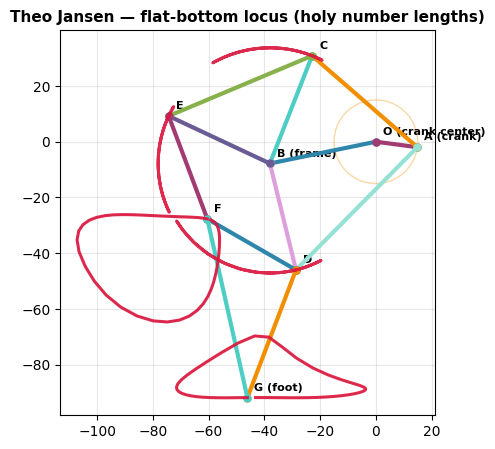

In [3]:
jansen = ls.Walker.from_jansen()
print(f'DOF: {jansen.dof}, feet: {jansen.get_feet()}')

show_walker(jansen, "Theo Jansen — flat-bottom locus (holy number lengths)")


## 3. Klann's 6-bar (US Patent 6,260,862)

Klann's linkage (6 links, one crank) approximates a scissor-gait pattern
with fewer parts than Jansen's. The foot lifts higher in swing — useful
for stepping over obstacles but worse for body stability.


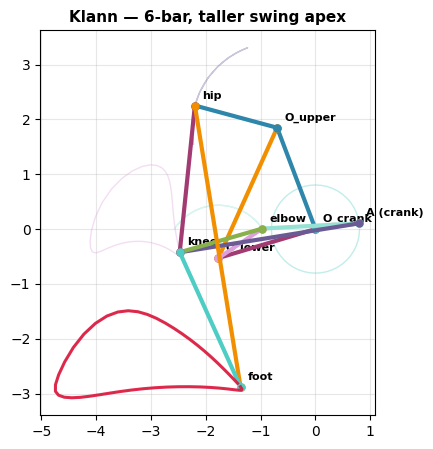

In [4]:
klann = ls.Walker.from_klann()
show_walker(klann, "Klann — 6-bar, taller swing apex")


## 4. Chebyshev's lambda (4-bar, 1850s)

The simplest mechanism here: a **four-bar** with a coupler point. The
classical Chebyshev ratio `crank:coupler:rocker:ground = 1:2.5:2.5:2`,
with the foot at a coupler **extension** past the coupler-rocker joint
(`foot_ratio=2.0` places it at distance `2 × coupler` from the crank
pin A — i.e., as far past B as A-B). The foot hangs below the
mechanism in a Λ-shape, and its lower stroke is the approximate
straight line this linkage is named for. Four bars is the minimum for
a 1-DOF single-leg mechanism.


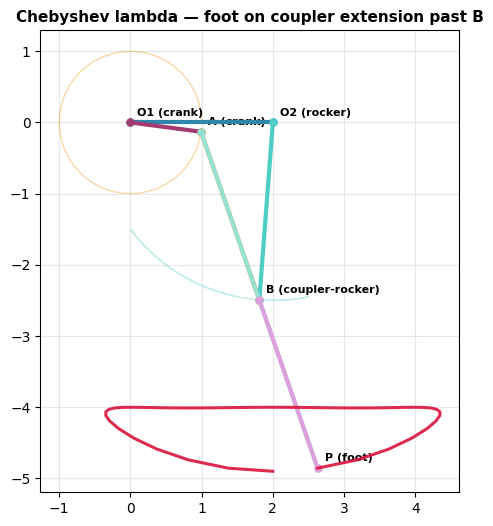

In [5]:
cheb = ls.Walker.from_chebyshev(
    crank=1.0, coupler=2.5, rocker=2.5, ground_length=2.0, foot_ratio=2.0,
)
show_walker(cheb, "Chebyshev lambda — foot on coupler extension past B",
            figsize=(8, 6))


## 5. Strider (Vagle / DIY Walkers)

Strider is a symmetric 10-bar popularized by Wade Vagle — two mirrored
four-bar stacks driven from a shared crank. It's the mechanism that
`sandbox_legged.py` at the monorepo root optimizes. Its default
rotation period is small (10 frames), so we pass a higher iteration
count for a smooth curve.


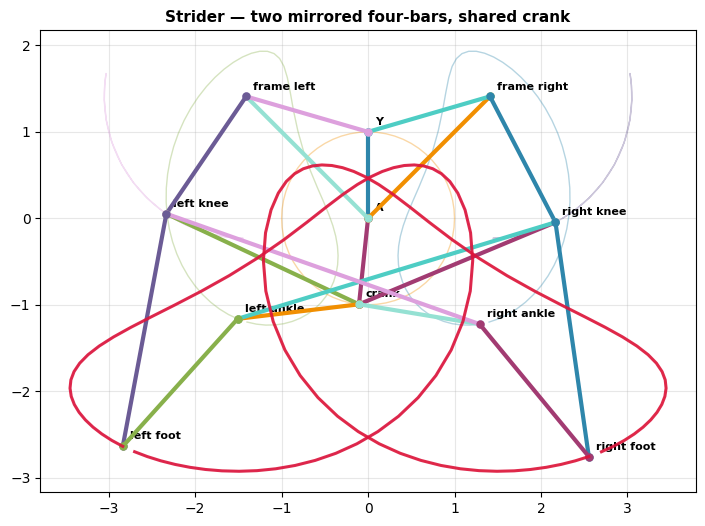

In [6]:
# Strider's factory angular velocity is coarse (10 steps per rotation);
# we pass a finer value so the foot curve is smooth in the plot.
from math import tau
strider = ls.Walker.from_strider(angular_velocity=-tau / 60)
show_walker(strider, "Strider — two mirrored four-bars, shared crank",
            figsize=(9, 6))


## 6. Ghassaei's 5-dyad (2011 Pomona thesis)

Amanda Ghassaei's leg is a five-RRR-dyad chain driven by a single
crank. `Walker.from_ghassaei()` uses the thesis's classical dimensions
(crank=26, ground=53, inner=56, outer=77, closing=75, H→E arm=130).
The H→E arm length is not given on Figure 5.4.4 and is tuned here to
reproduce the Wikibooks Walkin8r foot-locus aspect (x:y ≈ 1:0.24).


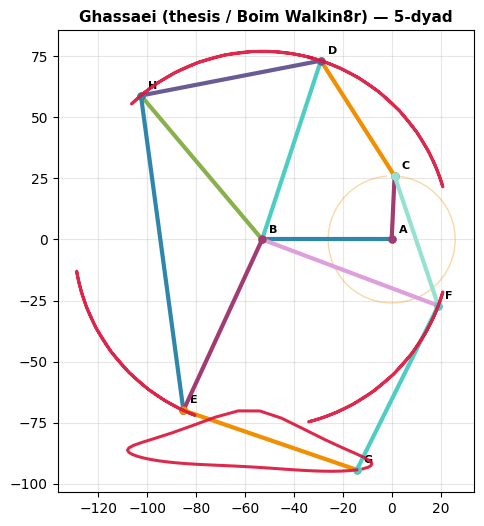

In [7]:
ghassaei = ls.Walker.from_ghassaei()
show_walker(ghassaei, "Ghassaei (thesis / Boim Walkin8r) — 5-dyad",
            figsize=(9, 6))


## 7. Watt I — a six-bar walker from the literature

The two six-bar families (Watt and Stephenson) open richer foot-path
geometries than a pure four-bar: classical synthesis uses them for
coupler-curve targets a 4-bar cannot reach.

The dimensions below come from Mehdigholi's Watt-6-bar walking
mechanism (also featured in
[kenaycock/Six-Bar-Walking-Mechanism](https://github.com/kenaycock/Six-Bar-Walking-Mechanism)).
They produce a non-Grashof four-bar A-B-C-D (the crank cannot rotate
full 360°), so we pass ``skip_unbuildable=True`` and visualize only
the buildable stroke — in a real walker two cranks would drive the
mechanism through the dead zone.


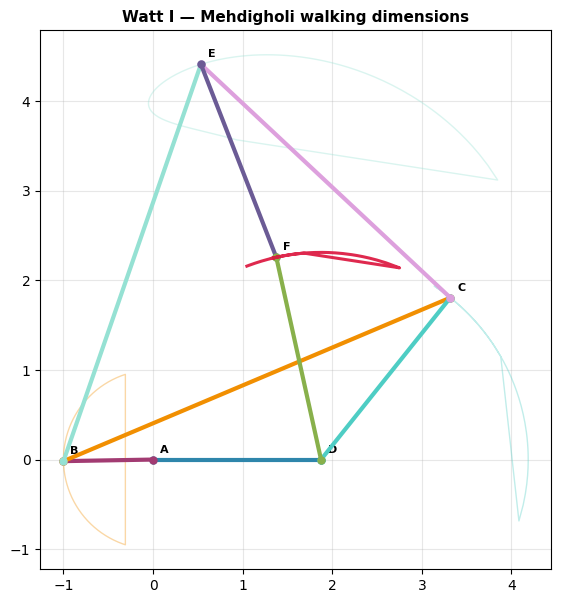

In [8]:
from math import pi

watt = ls.Walker.from_watt(
    crank=1.0,
    coupler1=4.6875,   # R3
    rocker1=2.3125,    # R4
    link4=4.6875,      # R6 (parallel leg link)
    link5=3.8125,      # R5 (top connector)
    rocker2=2.3125,    # R3'
    ground_length=1.875,  # R1
    initial_crank_angle=pi,
)
show_walker(watt, "Watt I — Mehdigholi walking dimensions",
            figsize=(8, 7), skip_unbuildable=True, foot_labels={'F'})


## 8. Stephenson I — synthesized from rigid-body poses

Where Watt's two rigid triangles are adjacent (joined at B), a
Stephenson has them **separated** — the second loop branches from
coupler joint C rather than crank-tip B.

Rather than handing it fixed dimensions, we run
`pylinkage.synthesis.motion_generation` with three target **poses**
(position + orientation) along a horizontal stroke, and Burmester
theory returns link lengths that thread those poses. The three poses
specify a body moving horizontally while rotating slightly — the
approximation of a walker's body during stance.

Pure collinear, same-orientation poses are singular under Burmester
synthesis (infinitely many solutions); the orientation sweep below
breaks that symmetry.


motion_generation → 5 four-bar solution(s)


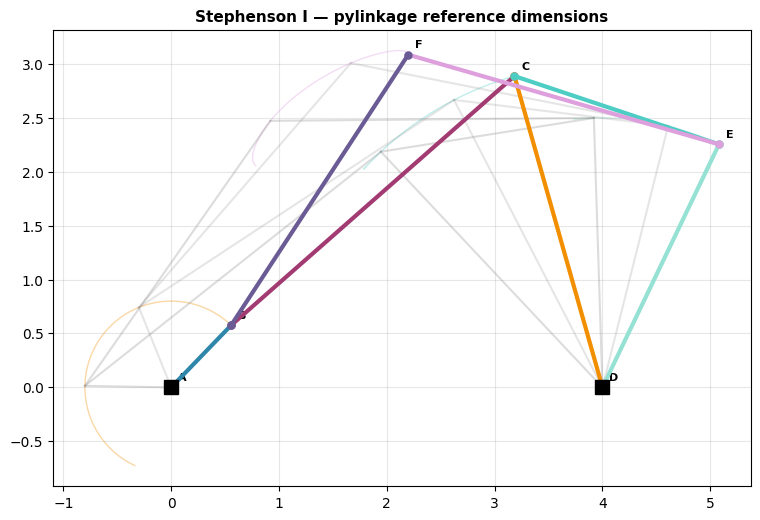

  pose 0: (0.0, 0.0, 0°)
  pose 1: (1.0, 0.5, 18°)
  pose 2: (2.0, 0.0, 36°)


In [9]:
import math
from pylinkage.synthesis import motion_generation, Pose, solution_to_linkage

# Three poses: horizontal motion with gentle orientation sweep
poses = [
    Pose(0.0, 0.0, 0.0),
    Pose(1.0, 0.5, math.pi / 10),
    Pose(2.0, 0.0, math.pi / 5),
]
syn = motion_generation(poses=poses, max_solutions=5, require_grashof=False)
print(f"motion_generation → {len(syn.solutions)} four-bar solution(s)")

# motion_generation returns four-bar solutions. To illustrate the
# Stephenson six-bar (and its separated ternary links), we use
# pylinkage's reference dimensions from its own notebook 14.
from pylinkage.synthesis import stephenson_from_lengths

stephenson = stephenson_from_lengths(
    crank=0.8, coupler=3.5, rocker=3.0,
    link4=2.0, link5=2.5, link6=3.0,
    ground_length=4.0, initial_crank_angle=math.pi / 4,
)
loci = list(stephenson.step(iterations=200))
fig, ax = plt.subplots(figsize=(9, 6))
plot_static_linkage(stephenson, ax, loci, show_loci=True, show_labels=True,
                    show_legend=False, n_ghosts=3,
                    title="Stephenson I — pylinkage reference dimensions")
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.show()

# Show what motion_generation placed the coupler through
for i, p in enumerate(poses):
    print(f"  pose {i}: ({p.x:.1f}, {p.y:.1f}, {math.degrees(p.angle):.0f}°)")


## Summary

| Mechanism   | Links | Defining property                          |
|-------------|-------|--------------------------------------------|
| Chebyshev   | 4     | Simplest — straight-line approximation     |
| Klann       | 6     | Scissor-gait, high swing apex              |
| Watt I      | 6     | Inline coupler, double-dwell curves         |
| Stephenson  | 6     | Branched coupler, wider coupler-curve space |
| Jansen      | 8     | Flat-bottom stance (Jansen's "holy number") |
| Strider     | 10    | Mirrored four-bars, symmetric gait          |
| Ghassaei    | 12    | Five-dyad chain, broad horizontal stride    |

Pick a factory as a starting point, then tune link lengths with the
optimization pipeline (notebook 03) or swap topologies entirely with
`topology_walking_optimization` (see `discover_walker.ipynb`).
